# Generalized Lagrangian Neural Networks (GLNN) — Paper Baseline
## Damped Harmonic Oscillator System

This notebook implements the **Generalized Lagrangian Neural Network (GLNN)** from the paper on physics-informed neural networks for non-conservative systems.

### System Dynamics
The experiment uses a **1D damped harmonic oscillator**:
$$\ddot{q} + a\dot{q} + \omega^2 q = 0$$

where:
- $\omega = 1.0$ (natural frequency)
- $a = 0.02$ (damping coefficient)
- Initial conditions: uniformly distributed in $[-1, 1]^2$

### Experiment Plan
1. **Generate synthetic data**: 40 trajectories × 200 time steps each = 8,000 point pairs
2. **Normalize**: Z-score normalization using training statistics only
3. **Train GLNN**: Standard MSE loss, 300 epochs, constant LR=0.001, batch_size=1000
4. **Evaluate**: One-step and rollout predictions on test set

### GLNN Architecture
- **Lagrangian Network (L-net)**: 3-layer Dense network (hidden=200) → scalar Lagrangian
- **Force Network (F-net)**: 3-layer Dense network (hidden=200) → d-dimensional non-conservative forces
- **Dynamics**: Generalized Lagrange equation with standard PyTorch autodiff (no vmap, no force library)

In [1]:
# ── Cell 2
# Core utilities
import os
import time
import warnings
import random
from argparse import Namespace

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random as jax_random

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

JAX_KEY = None

def seed_everything(seed=42):
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

seed_everything(42)
print('✓ All required libraries imported and configured.')

✓ All required libraries imported and configured.


In [2]:
# ── Cell 3 (Physical System: Compound Double Pendulum with Friction) ───────
from jax import random as jax_random

# System and data configuration
# NOTE: DIMENSION = number of generalized coordinates (theta1, theta2) -> state is 2*DIMENSION = 4
DIMENSION = 2
MASS = 1.0             # m: mass of each pendulum body (kg)
AXLE_SEPARATION = 1.0  # d: distance between the two axles P and Q (m)
GRAVITY = 10.0          # g: acceleration due to gravity (m/s^2) -- matches paper's numerical setup
GAMMA_1 = 0.5           # friction coefficient at axle 1 (P)
GAMMA_2 = 0.5           # friction coefficient at axle 2 (Q)

# ASSUMPTION (flagged): eq. (12) only involves I directly, not c. The excerpt
# doesn't give I explicitly, so we assume a uniform rod of length =
# AXLE_SEPARATION pivoted at its end: I = (1/3) m d^2.
# If you have the paper's actual I (or c) value, change this one line.
MOMENT_OF_INERTIA = (1.0 / 3.0) * MASS * AXLE_SEPARATION ** 2

N_TRAJECTORIES = 40
PTS_PER_TRAJECTORY = 201
H_DATA_GEN = 0.05

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step."""
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)
    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)
    return q_new, deriv

def _compound_double_pendulum_trajectory(n_points, d, m=1.0, dist=1.0, I=1.0,
                                          g=10.0, gamma1=0.5, gamma2=0.5,
                                          dt=0.05, q0=None):
    """
    Generate a single trajectory using RK4 integration (JAX).

    State: [theta1, theta2, theta1_dot, theta2_dot]   (d = 2 generalized coords)

    Coupled equations of motion (paper eq. 12):
      -g1*th1d - g2*(th1d - th2d) = (2md^2 + I)*th1dd + md^2*cos(th1-th2)*th2dd
                                     + md^2*th2d^2*sin(th1-th2) + 2mgd*sin(th1)
       g2*(th1d - th2d)           = md^2*cos(th1-th2)*th1dd + (md^2 + I)*th2dd
                                     - md^2*th1d^2*sin(th1-th2) + mgd*sin(th2)

    Solved as a 2x2 linear system M @ theta_ddot = rhs at every step.
    """
    if q0 is None:
        global JAX_KEY
        JAX_KEY, subkey = jax_random.split(JAX_KEY, 2)
        # Paper: initial state (theta1, theta2, theta1_dot, theta2_dot) drawn
        # uniformly from [-1, 1]^4
        q0 = jax_random.uniform(subkey, shape=(2 * d,), minval=-1.0, maxval=1.0)

    def dynamics(state):
        """Compute state derivatives: [th1d, th2d, th1dd, th2dd]"""
        th1, th2 = state[0], state[1]
        th1d, th2d = state[2], state[3]
        delta = th1 - th2

        md2 = m * dist ** 2
        c, s = jnp.cos(delta), jnp.sin(delta)

        M = jnp.array([[2 * md2 + I,   md2 * c],
                        [md2 * c,       md2 + I]])

        rhs = jnp.array([
            -gamma1 * th1d - gamma2 * (th1d - th2d) - md2 * (th2d ** 2) * s - 2 * m * g * dist * jnp.sin(th1),
             gamma2 * (th1d - th2d) + md2 * (th1d ** 2) * s - m * g * dist * jnp.sin(th2)
        ])

        theta_ddot = jnp.linalg.solve(M, rhs)
        return jnp.concatenate([jnp.array([th1d, th2d]), theta_ddot])

    states = [q0]
    derivs = []
    q = q0
    for _ in range(n_points - 1):
        q_new, deriv = rk4_step(q, dynamics, dt)
        states.append(q_new)
        derivs.append(deriv)
        q = q_new

    return jnp.stack(states), jnp.stack(derivs)

print('Configured Compound Double Pendulum with Friction (Paper Section 4.3) - JAX:')
print(f'  State: [θ1, θ2, θ̇1, θ̇2] (4D) | Mass: {MASS} | Axle sep d: {AXLE_SEPARATION} | I: {MOMENT_OF_INERTIA:.4f}')
print(f'  Friction: γ1={GAMMA_1}, γ2={GAMMA_2} | g={GRAVITY}')
print(f'  Trajectories: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points = {N_TRAJECTORIES * PTS_PER_TRAJECTORY} point pairs')
print(f'  Initial conditions: (θ1,θ2,θ̇1,θ̇2) ∈ [-1, 1]^4')

Configured Compound Double Pendulum with Friction (Paper Section 4.3) - JAX:
  State: [θ1, θ2, θ̇1, θ̇2] (4D) | Mass: 1.0 | Axle sep d: 1.0 | I: 0.3333
  Friction: γ1=0.5, γ2=0.5 | g=10.0
  Trajectories: 40 × 201 points = 8040 point pairs
  Initial conditions: (θ1,θ2,θ̇1,θ̇2) ∈ [-1, 1]^4


In [3]:
# ── Cell 4: Generate & Split Synthetic Data ───────────────────
print('Generating compound double pendulum (friction) data (40 trajectories × 200 points)...')

all_states = []
all_derivs = []

for traj_idx in range(N_TRAJECTORIES):
    states, derivs = _compound_double_pendulum_trajectory(
        PTS_PER_TRAJECTORY, DIMENSION,
        m=MASS, dist=AXLE_SEPARATION, I=MOMENT_OF_INERTIA,
        g=GRAVITY, gamma1=GAMMA_1, gamma2=GAMMA_2, dt=H_DATA_GEN
    )
    all_states.append(np.array(states))
    all_derivs.append(np.array(derivs))

gt_trajectory = all_states[0]
gt_derivatives = all_derivs[0]
gt_initial_condition = gt_trajectory[0]

x_data = np.concatenate([states[:-1] for states in all_states], axis=0)
y_data = np.concatenate([states[1:] for states in all_states], axis=0)

split_idx = len(x_data) // 2
x_tr, y_tr = x_data[:split_idx], y_data[:split_idx]
x_te, y_te = x_data[split_idx:], y_data[split_idx:]

print(f"""✓ Data generated: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} = {len(x_data)} pairs
  Train/Test: {len(x_tr)} / {len(x_te)}
  Reference trajectory (Trajectory 0): θ1₀={gt_initial_condition[0]:.4f}, θ2₀={gt_initial_condition[1]:.4f}, θ̇1₀={gt_initial_condition[2]:.4f}, θ̇2₀={gt_initial_condition[3]:.4f}""")

Generating compound double pendulum (friction) data (40 trajectories × 200 points)...
✓ Data generated: 40 × 201 = 8000 pairs
  Train/Test: 4000 / 4000
  Reference trajectory (Trajectory 0): θ1₀=0.4553, θ2₀=0.5757, θ̇1₀=-0.6366, θ̇2₀=-0.4747


In [4]:
# ── Cell 5
# Verify and summarize compound double pendulum (friction) data

corr_12 = np.corrcoef(x_tr[:, 0], x_tr[:, 1])[0, 1]
deriv_stats = y_tr.mean(axis=0), y_tr.std(axis=0)

print(f"""--- Compound Double Pendulum (Friction) Data Summary ---
Physics Setup:
  System: 2-DOF Compound Double Pendulum with Friction (eq. 12)
  Params: m={MASS}, d={AXLE_SEPARATION}, I={MOMENT_OF_INERTIA:.4f}, g={GRAVITY}, γ1={GAMMA_1}, γ2={GAMMA_2}
  Initial conditions: (θ1,θ2,θ̇1,θ̇2) ∈ [-1, 1]^4

Dataset Configuration:
  Trajectories: {N_TRAJECTORIES}
  Points per trajectory: {PTS_PER_TRAJECTORY}
  Time step (dt): {H_DATA_GEN}
  Total point pairs: {len(x_data)}
  Train/Test split: 1:1 → Train={len(x_tr)}, Test={len(x_te)}

[Raw Statistics: Mean | Std | Min | Max]
  θ1:  {x_tr[:, 0].mean():.4f} | {x_tr[:, 0].std():.4f} | {x_tr[:, 0].min():.4f} | {x_tr[:, 0].max():.4f}
  θ2:  {x_tr[:, 1].mean():.4f} | {x_tr[:, 1].std():.4f} | {x_tr[:, 1].min():.4f} | {x_tr[:, 1].max():.4f}
  θ̇1:  {x_tr[:, 2].mean():.4f} | {x_tr[:, 2].std():.4f} | {x_tr[:, 2].min():.4f} | {x_tr[:, 2].max():.4f}
  θ̇2:  {x_tr[:, 3].mean():.4f} | {x_tr[:, 3].std():.4f} | {x_tr[:, 3].min():.4f} | {x_tr[:, 3].max():.4f}

[Derivative (Target) Statistics]
  Mean: {deriv_stats[0].round(6)}
  Std:  {deriv_stats[1].round(6)}

[Physics Verification]
  θ1-θ2 correlation: {corr_12:.4f} (coupling between the two arms)
-------------------------------------------""")

--- Compound Double Pendulum (Friction) Data Summary ---
Physics Setup:
  System: 2-DOF Compound Double Pendulum with Friction (eq. 12)
  Params: m=1.0, d=1.0, I=0.3333, g=10.0, γ1=0.5, γ2=0.5
  Initial conditions: (θ1,θ2,θ̇1,θ̇2) ∈ [-1, 1]^4

Dataset Configuration:
  Trajectories: 40
  Points per trajectory: 201
  Time step (dt): 0.05
  Total point pairs: 8000
  Train/Test split: 1:1 → Train=4000, Test=4000

[Raw Statistics: Mean | Std | Min | Max]
  θ1:  -0.0005 | 0.2195 | -0.9975 | 0.7956
  θ2:  -0.0062 | 0.3403 | -0.9775 | 0.9786
  θ̇1:  -0.0105 | 0.5379 | -2.4515 | 2.6496
  θ̇2:  0.0242 | 0.8032 | -2.6202 | 2.7413

[Derivative (Target) Statistics]
  Mean: [-0.00103  -0.004961 -0.009971  0.024886]
  Std:  [0.216744 0.338414 0.537032 0.802201]

[Physics Verification]
  θ1-θ2 correlation: 0.7768 (coupling between the two arms)
-------------------------------------------


Total dataset size    : 4000 points
Active points (>1e-4) : 4000 points
Dead points (≤1e-4)   : 0 (0.00%)


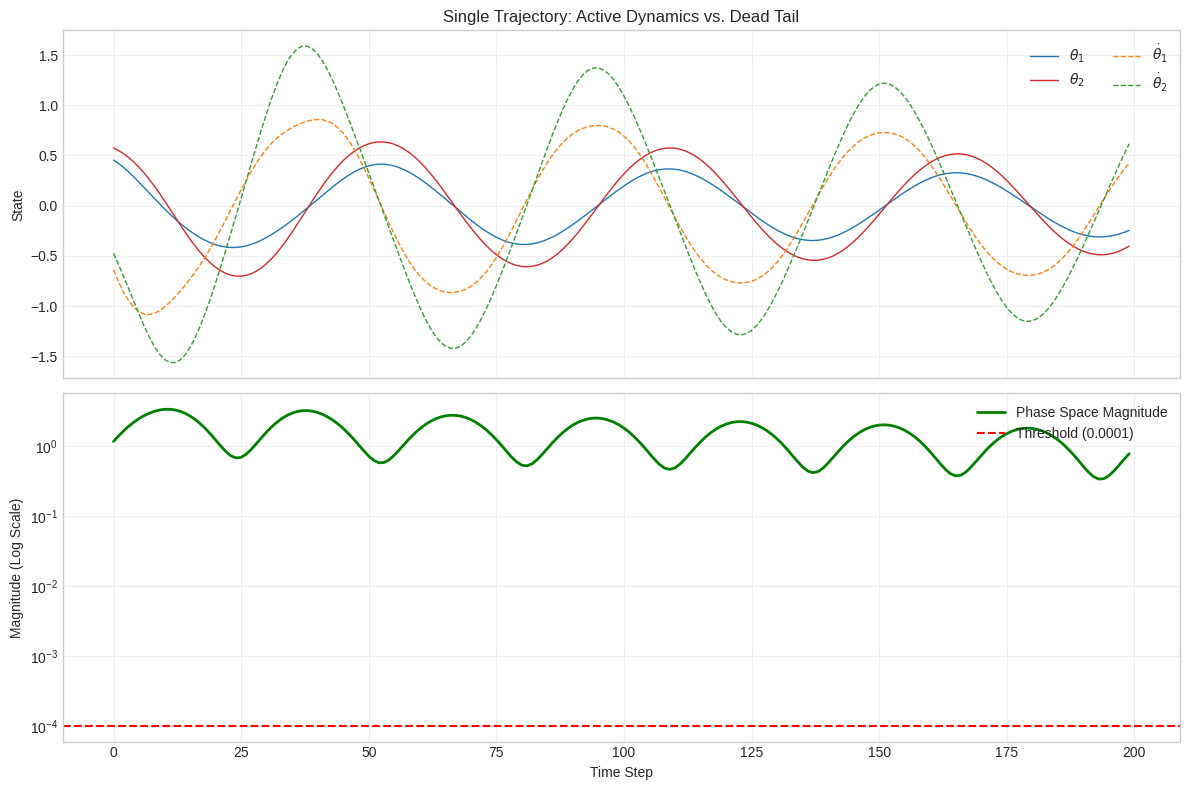

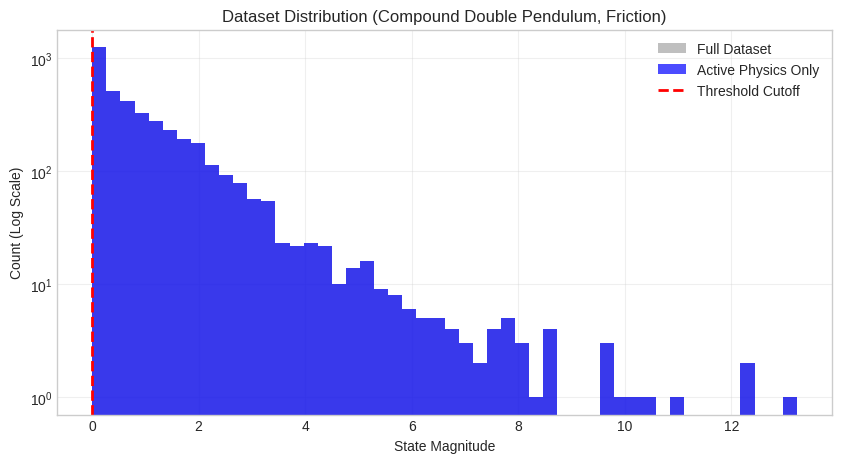

In [5]:
# ── Cell 6 (Energy/Magnitude Threshold Analysis in JAX)
energy_threshold = 1e-4

x_tr_jax = jnp.array(x_tr)

# State magnitude over all 4 components: theta1^2+theta2^2+theta1dot^2+theta2dot^2
state_magnitude_jax = jnp.sum(x_tr_jax**2, axis=-1)
state_magnitude = np.array(state_magnitude_jax)

active_indices_jax = state_magnitude_jax > energy_threshold
active_indices = np.array(active_indices_jax)

orig_size = len(x_tr)
new_size = int(np.sum(active_indices))
print(f"Total dataset size    : {orig_size} points")
print(f"Active points (>1e-4) : {new_size} points")
print(f"Dead points (≤1e-4)   : {orig_size - new_size} ({(1 - new_size/orig_size)*100:.2f}%)")

time_steps = PTS_PER_TRAJECTORY - 1
single_traj = x_tr[:time_steps]
single_mag = state_magnitude[:time_steps]
is_active = active_indices[:time_steps]
cutoff_idx = int(np.argmax(~is_active)) if not is_active.all() else time_steps

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
t = np.arange(time_steps)

ax1.plot(t, single_traj[:, 0], label='$\\theta_1$', color='#1f77b4', linewidth=1)
ax1.plot(t, single_traj[:, 1], label='$\\theta_2$', color='#d62728', linewidth=1)
ax1.plot(t, single_traj[:, 2], label='$\\dot{\\theta}_1$', color='#ff7f0e', linewidth=1, linestyle='--')
ax1.plot(t, single_traj[:, 3], label='$\\dot{\\theta}_2$', color='#2ca02c', linewidth=1, linestyle='--')
if cutoff_idx < time_steps:
    ax1.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15, label='Dead Tail Region')
ax1.set_ylabel('State')
ax1.set_title('Single Trajectory: Active Dynamics vs. Dead Tail')
ax1.legend(loc='upper right', ncol=2)
ax1.grid(True, alpha=0.3)

ax2.plot(t, single_mag, label='Phase Space Magnitude', color='green', linewidth=2)
ax2.axhline(energy_threshold, color='red', linestyle='--', label=f'Threshold ({energy_threshold})')
if cutoff_idx < time_steps:
    ax2.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Magnitude (Log Scale)')
ax2.set_yscale('log')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
mag_active = state_magnitude[active_indices]
plt.hist(state_magnitude, bins=50, alpha=0.5, label='Full Dataset', color='gray')
plt.hist(mag_active, bins=50, alpha=0.7, label='Active Physics Only', color='blue')
plt.axvline(energy_threshold, color='red', linestyle='dashed', linewidth=2, label='Threshold Cutoff')
plt.yscale('log')
plt.title('Dataset Distribution (Compound Double Pendulum, Friction)')
plt.xlabel('State Magnitude')
plt.ylabel('Count (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ── Cell 7
import flax.linen as nn

DOF = 2
EPS = 1e-3        # Mass matrix regularization

# ─────────────────────────────────────────────────────────────────────────────
# 1) Lagrangian Network (L-net)
# ─────────────────────────────────────────────────────────────────────────────
class LagrangianNet(nn.Module):
    """
    Lagrangian Network: Maps (q, q̇) → scalar Lagrangian L = T - U

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output initialization: N(0, 1e-4)
    """
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: scalar Lagrangian
        # Weight ~ N(0, 1e-4), Bias = 0.0
        x = nn.Dense(
            features=1,
            kernel_init=jax.nn.initializers.normal(stddev=1e-4),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return jnp.squeeze(x, axis=-1)


# ─────────────────────────────────────────────────────────────────────────────
# 2) Force Network (F-net)
# ─────────────────────────────────────────────────────────────────────────────
class ForceNet(nn.Module):
    """
    Force Network: Maps (q, q̇) → d-dimensional non-conservative force F_k

    This network learns the non-conservative generalized forces in the
    generalized Lagrange equation:
        d/dt(∂L/∂q̇_k) - ∂L/∂q_k = F_k

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output: d-dimensional force vector
    """
    hidden_dim: int = 200
    output_dim: int = 1  # d (degrees of freedom)

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: d-dimensional force vector
        # Initialize to near-zero to start with conservative dynamics
        x = nn.Dense(
            features=self.output_dim,
            kernel_init=jax.nn.initializers.normal(stddev=1e-4),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return x


# ─────────────────────────────────────────────────────────────────────────────
# 3) Hybrid GLNN with both L-net and F-net
# ─────────────────────────────────────────────────────────────────────────────
class HybridGLNNMASS:
    """
    Generalized Lagrangian Neural Network (GLNN) for non-conservative systems.

    Implements the generalized Lagrange equation:
        q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F]

    where:
      - L: Lagrangian learned by L-net
      - F: Non-conservative forces learned by F-net
    """
    def __init__(self, d, hidden_dim=200):
        self.d = d
        self.l_net = LagrangianNet(hidden_dim=hidden_dim)
        self.f_net = ForceNet(hidden_dim=hidden_dim, output_dim=d)

    def init(self, key, x):
        """Initialize both L-net and F-net parameters."""
        # Split concatenated input [q, q_dot] into separate components
        q, q_t = jnp.split(x, 2, axis=-1)

        # Initialize L-net
        key, subkey = jax.random.split(key)
        l_params = self.l_net.init(subkey, q, q_t)

        # Initialize F-net
        key, subkey = jax.random.split(key)
        f_params = self.f_net.init(subkey, q, q_t)

        # Combine both parameter sets
        params = {'l_net': l_params, 'f_net': f_params}
        return params

    def dstate(self, x, params):
        """
        Compute state derivatives using the generalized Lagrange equation.

        Args:
            x: State vector [q, q̇] with shape (d,) or (batch, d)
            params: Dict containing 'l_net' and 'f_net' parameters

        Returns:
            State derivative [q̇, q̈]
        """
        # Split state back into q and q_t
        q, q_t = jnp.split(x, 2, axis=-1)

        # Define pure functions for autodiff
        def lagrangian(q, q_t):
            return self.l_net.apply(params['l_net'], q, q_t)

        def force(q, q_t):
            return self.f_net.apply(params['f_net'], q, q_t)

        # Compute Lagrangian derivatives
        l_grad_q = jax.grad(lagrangian, 0)(q, q_t)              # ∂L/∂q
        l_grad_q_t = jax.grad(lagrangian, 1)(q, q_t)            # ∂L/∂q̇
        l_hess_q_t_q_t = jax.hessian(lagrangian, 1)(q, q_t)    # ∇q̇∇_q̇ L
        l_grad_q_grad_q_t = jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t)  # ∇_q∇_q̇ L

        # Compute non-conservative forces
        F = force(q, q_t)

        # Generalized Lagrange equation:
        # q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F]
        mass_matrix = l_hess_q_t_q_t + EPS * jnp.eye(self.d)
        rhs = l_grad_q - l_grad_q_grad_q_t @ q_t + F

        # Solve for acceleration using pseudo-inverse for numerical stability
        q_tt = jnp.linalg.pinv(mass_matrix) @ rhs

        # Return state derivative [q̇, q̈]
        return jnp.concatenate([q_t, q_tt], axis=-1)

    def forward(self, x, params):
        """Forward pass: compute one-step RK4 integration."""
        def dynamics_fn(state):
            return self.dstate(state, params)
        dt = H_DATA_GEN  # 0.05
        q_next, _ = rk4_step(x, dynamics_fn, dt)
        return q_next
        # return self.dstate(x, params)

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H_DATA_GEN):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'F-net           : 3x Dense(200)-Softplus → {DOF}D (Non-conservative Forces)')

GLNN configured : DOF=2  dt=0.0500s  EPS=0.001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
F-net           : 3x Dense(200)-Softplus → 2D (Non-conservative Forces)


In [12]:
# ── Cell 8
#  Training with 4-Stage Curriculum Learning (PyTorch) ──────────

import optax
from functools import partial

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Curriculum Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def curriculum_loss_fn(params, model, xb, yb, xsb, ysb, delta_scale, l2_coef, ss_prob, alpha, key):
    """
    Computes the curriculum loss for a single system using K-step rollout.

    Args:
        params: PyTree of model weights.
        model: Flax module instance to provide the forward method.
        xb, yb: Z-score normalized (Batch, Features) inputs/targets for single-step loss.
        xsb, ysb: (Batch, Features) and (Batch, K, Features) arrays for K-step rollout.
        delta_scale: JAX array scaling factor for Z-score de-normalization in Sc-MSE.
        l2_coef: Coefficient applied to L2 weight decay.
        ss_prob: Scheduled sampling probability for using predictions vs ground truth.
        alpha: Weighting factor blending single-step (loss1) and rollout loss (loss_k).
        key: PRNG key for scheduled sampling stochasticity.

    Returns:
        total_loss: The blended, regularized scalar loss for gradient computation.
        loss_k: The raw K-step rollout Sc-MSE used for logging.
    """
    # Create batched forward function
    batch_forward = jax.vmap(model.forward, in_axes=(0, None))

    # 1. Single Step Loss
    pred1 = batch_forward(xb, params)
    loss1 = jnp.mean(((pred1 - yb) / delta_scale) ** 2)

    # 2. K-Step Rollout Loss using concise lax.scan
    K = ysb.shape[1]
    step_weights = jnp.linspace(1.0, 2.2, K)

    def step_fn(carry, inputs):
        current_state, rng_key = carry
        target_k, weight = inputs

        # Forward pass
        pred_k = batch_forward(current_state, params)
        err_k = jnp.mean(((pred_k - target_k) / delta_scale) ** 2)

        # Scheduled sampling
        rng_key, subkey = jax.random.split(rng_key)
        use_pred = jax.random.uniform(subkey, (current_state.shape[0], 1)) < ss_prob
        next_state = jnp.where(use_pred, pred_k, target_k)

        return (next_state, rng_key), weight * err_k

    # Loss function: Run the rollout over the K dimension
    keys = jax.random.split(key)
    _, weighted_errs = jax.lax.scan(
        step_fn,
        (xsb, keys[1]),
        (jnp.transpose(ysb, (1, 0, 2)), step_weights) # Transpose ysb to (K, BATCH, FEATURES)
    )

    loss_k = jnp.sum(weighted_errs) / jnp.sum(step_weights)

    # 3. Regularization (L2 Only)
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # Total Blended Loss
    total_loss = (1.0 - alpha) * loss1 + alpha * loss_k + (l2_coef * l2_reg)

    return total_loss, loss_k

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, xsb, ysb, delta_scale, l2_coef, ss_prob, alpha, key):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(curriculum_loss_fn, has_aux=True)

    (total_loss, loss_k), grads = grad_fn(
        params, model, xb, yb, xsb, ysb, delta_scale, l2_coef, ss_prob, alpha, key
    )

    # Optimizer step (No clipping per instructions)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, loss_k

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, K, ss_prob, alpha, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    # 1. Generate Batched indices
    max_idx = len(Xs) - K - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    # 2. Gather Data (Input dimension automatically resolved to 2 based on provided arrays)
    xb = Xs[start_idxs]
    yb = Ys[start_idxs]
    xsb = xb

    # Gather dynamic sequences for Y
    def get_seq(idx):
        return jax.lax.dynamic_slice_in_dim(Ys, idx, K)
    ysb = jax.vmap(get_seq)(start_idxs)

    # 3. Take Optimization Step
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, loss_k = update_step(
        model, tx, params, opt_state, xb, yb, xsb, ysb, delta_scale, 1e-5, ss_prob, alpha, dropout_key
    )

    # 4. Logging & Sync
    if iter_count % 500 == 0:
        total_loss.block_until_ready() # JAX equivalent of cuda.synchronize()
        total_elapsed = time.perf_counter() - training_start
        print(
            f"[Iter {iter_count:5d}] "
            f"Sys 0 | "  # Hardcoded since we are down to 1 system
            f"K={K:2d} | "
            f"Sc-MSE: {float(loss_k)/K:.2e} | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, delta_scale, Xs, Ys):
    print(f'Device: {jax.devices()[0]}')

    # 1. Initialize Model & State
    model = HybridGLNNMASS(d=args.dimension)

    key = jax.random.PRNGKey(42)
    key, init_key = jax.random.split(key)

    # If d=1, features=2 (q, q_dot)
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n━━━ Training System ━━━')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    # optax linear schedule equivalent to PyTorch's LinearLR
    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    tx1 = optax.adamw(learning_rate=schedule1, weight_decay=1e-4) # PyTorch had 1e-4
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        K = 1
        ss_prob = 0.0
        alpha = 1.0

        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, K, ss_prob, alpha,
            global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    # print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')

    # # optax cosine decay equivalent to PyTorch's CosineAnnealingLR
    # schedule2 = optax.cosine_decay_schedule(
    #     init_value=args.lr,
    #     decay_steps=args.iterations_2
    # )
    # tx2 = optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    # # Re-initialize the opt_state for stage 2, matching the PyTorch behavior
    # # of creating a brand new optimizer which resets momentum and variance stats
    # opt_state2 = tx2.init(params)

    # for step in range(args.iterations_2):
    #     K = 1
    #     ss_prob = 0.0
    #     alpha = 1.0

    #     params, opt_state2, avg_loss, global_iter, key = train_loop(
    #         model, tx2, params, opt_state2, K, ss_prob, alpha,
    #         global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
    #     )
    #     loss_history.append(float(avg_loss))

    # # Save model parameters
    # # Note: In JAX, we save the `params` dictionary using libraries like `orbax` or `flax.training.checkpoints`.
    # # For simplicity, we just print the directory here as requested in the structure.
    # os.makedirs(args.pt_dir, exist_ok=True)
    # print(f'\n✅ Training complete. Model params ready to be saved to {args.pt_dir}/final_model.msgpack (or similar)')

    return np.array(loss_history), params, model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JAX automatically selects the fastest available accelerator (GPU/TPU)
device = jax.devices()[0]
print(f"Using device: {device}")

# Compute standardization scales using standard NumPy
delta_scale = y_tr.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

# Prepare data tensors using jax.numpy
Xs = jnp.array(x_tr, dtype=jnp.float32)
Ys = jnp.array(y_tr, dtype=jnp.float32)
delta_scale_jax = jnp.array(delta_scale, dtype=jnp.float32)

# Create training configuration
# Note: total_systems and l1_weight are omitted here as we simplified
# the architecture to a single system with L2-only regularization previously.
args = Namespace(
    dimension=2,         # Degrees of freedom (d=1 means state size is 2: q, q_dot)
    lr=3e-4,             # Peak learning rate
    iterations_1=10000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING JAX TRAINING":^80}')
print(f'{"="*80}')

training_start = time.perf_counter()

# Call the JAX main function from the previous cell
loss_arr, final_params, dnn = main(args, delta_scale_jax, Xs, Ys)

# Force synchronization at the end to get an accurate total time
# Converting to a standard numpy array blocks until the GPU queue finishes
loss_arr = np.array(loss_arr)
total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Using device: cuda:0

                             STARTING JAX TRAINING                              
Device: cuda:0

━━━ Training System ━━━
Stage 1: Warmup (10000 iterations)
[Iter   500] Sys 0 | K= 1 | Sc-MSE: 2.21e-04 | Total Time: 0.65 min
[Iter  1000] Sys 0 | K= 1 | Sc-MSE: 3.47e-04 | Total Time: 0.85 min
[Iter  1500] Sys 0 | K= 1 | Sc-MSE: 1.68e-04 | Total Time: 1.06 min
[Iter  2000] Sys 0 | K= 1 | Sc-MSE: 8.45e-05 | Total Time: 1.27 min
[Iter  2500] Sys 0 | K= 1 | Sc-MSE: 5.91e-04 | Total Time: 1.47 min
[Iter  3000] Sys 0 | K= 1 | Sc-MSE: 2.20e-04 | Total Time: 1.68 min
[Iter  3500] Sys 0 | K= 1 | Sc-MSE: 1.75e-04 | Total Time: 1.88 min
[Iter  4000] Sys 0 | K= 1 | Sc-MSE: 9.22e-05 | Total Time: 2.10 min
[Iter  4500] Sys 0 | K= 1 | Sc-MSE: 1.12e-04 | Total Time: 2.30 min
[Iter  5000] Sys 0 | K= 1 | Sc-MSE: 1.90e-04 | Total Time: 2.51 min
[Iter  5500] Sys 0 | K= 1 | Sc-MSE: 2.73e-04 | Total Time: 2.72 min
[Iter  6000] Sys 0 | K= 1 | Sc-MSE: 9.71e-05 | Total Time: 2.93 min
[Iter 

In [13]:
# ── Cell 9: Evaluation Utilities + Wrapper (JAX) ─────────────────────────

class EvalWrapper:
    def __init__(self, model, params):
        """
        Binds the Flax model and trained parameters together for easier evaluation,
        mimicking a stateful PyTorch module API.
        """
        self.model = model
        self.params = params

        # JIT compile batched versions of the functions for maximum evaluation speed
        self.batched_forward = jax.jit(jax.vmap(self.model.forward, in_axes=(0, None)))
        self.batched_dstate = jax.jit(jax.vmap(self.model.dstate, in_axes=(0, None)))

    def _format_input(self, x):
        """Ensures the input is a JAX array and adds a batch dim if necessary."""
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]  # Shape (1, Features)
        return x, is_single

    def dstate(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_dstate(x, self.params)
        return out[0] if is_single else out

    def __call__(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_forward(x, self.params)
        return out[0] if is_single else out


def one_step_mse_jax(wrapper, x_data, y_data):
    """Compute one-step MSE prediction error."""
    # Convert to JAX arrays just in case they are numpy
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)

    # Wrapper handles batching automatically
    pred = wrapper(x_data)
    mse = jnp.mean((pred - y_data) ** 2)

    # Return as standard Python float
    return float(mse)


@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, params, x0, n_steps):
    """Internal JIT-compiled loop for lightning fast rollouts."""
    def step_fn(current_state, _):
        next_state = model.forward(current_state, params)
        # return (carry, output)
        return next_state, next_state

    # lax.scan loops n_steps - 1 times efficiently on the GPU
    _, trajectory = jax.lax.scan(step_fn, x0, None, length=n_steps - 1)

    # Prepend the initial state to the trajectory
    return jnp.concatenate([x0[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    """Generate rollout trajectory starting from x0 for n_steps."""
    x0 = jnp.array(x0, dtype=jnp.float32)

    # Ensure x0 is strictly 1D (Features,)
    if x0.ndim > 1:
        x0 = x0.squeeze()

    # Run compiled rollout
    traj = _compiled_rollout(wrapper.model, wrapper.params, x0, n_steps)

    # Return as a standard NumPy array for easy plotting/external use
    return np.array(traj)

print("✓ Evaluation utilities loaded (JAX simplified wrapper).")

✓ Evaluation utilities loaded (JAX simplified wrapper).


In [14]:
# ── Cell 10: Evaluate One-Step MSE + Integrate Learned Dynamics ───────────
from scipy.integrate import solve_ivp
import numpy as np

# Evaluate on training and test sets (one-step predictions)
eval_model = EvalWrapper(dnn, final_params)
mse_tr = one_step_mse_jax(eval_model, x_tr, y_tr)
mse_te = one_step_mse_jax(eval_model, x_te, y_te)

print(f'One-Step MSE:')
print(f'  Train: {mse_tr:.4e}')
print(f'  Test:  {mse_te:.4e}')
print(f'  Gap:   {(mse_te/mse_tr - 1)*100:.1f}%')

def lnn_dynamics_wrapper(t, state_vec):
    """
    Wrapper for Scipy ODE solver: converts (theta1, theta2, theta1_dot, theta2_dot)
    to [theta1_dot, theta2_dot, theta1_ddot_pred, theta2_ddot_pred] using JAX.
    """
    dstate_pred = eval_model.dstate(state_vec)
    return np.array(dstate_pred)

# Integrate the GLNN from the reference initial condition
t_span = (0.0, (len(gt_trajectory) - 1) * H_DATA_GEN)
t_eval = np.arange(len(gt_trajectory)) * H_DATA_GEN

print(f"\n✓ Integrating GLNN dynamics using ODE solver:")
print(f"  Initial condition: θ1={gt_initial_condition[0]:.4f}, θ2={gt_initial_condition[1]:.4f}, "
      f"θ̇1={gt_initial_condition[2]:.4f}, θ̇2={gt_initial_condition[3]:.4f}")
print(f"  Integration time: t ∈ [{t_span[0]:.3f}, {t_span[1]:.3f}] seconds")
print(f"  Number of evaluation points: {len(t_eval)}")

sol = solve_ivp(
    lnn_dynamics_wrapper,
    t_span,
    gt_initial_condition.flatten(),
    t_eval=t_eval,
    method='DOP853',
    dense_output=False,
    max_step=H_DATA_GEN
)

if sol.status != 0:
    print(f"⚠️  ODE solver warning: {sol.message}")

traj_pred = sol.y.T  # Transpose to (n_steps, 4)
traj_gt = gt_trajectory

print(f"✓ ODE integration complete: {len(traj_pred)} timesteps")

One-Step MSE:
  Train: 6.4162e-05
  Test:  8.7651e-05
  Gap:   36.6%

✓ Integrating GLNN dynamics using ODE solver:
  Initial condition: θ1=0.4553, θ2=0.5757, θ̇1=-0.6366, θ̇2=-0.4747
  Integration time: t ∈ [0.000, 10.000] seconds
  Number of evaluation points: 201
✓ ODE integration complete: 201 timesteps


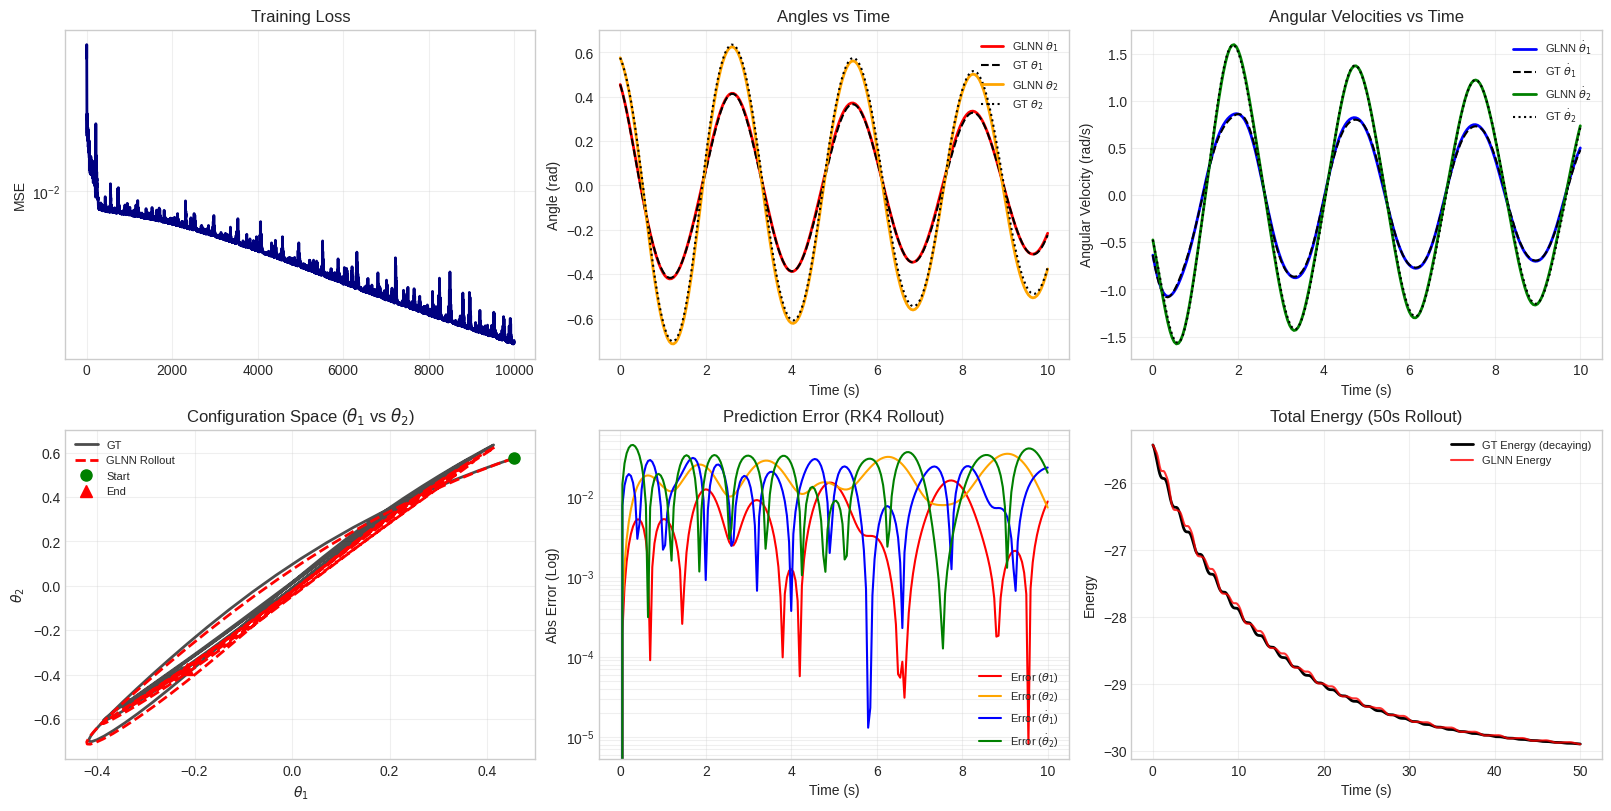


    COMPOUND DOUBLE PENDULUM (FRICTION) - RK4 ROLLOUT DIAGNOSTICS     
Short Trajectory:     201 timesteps (10.050 s)
Mean θ1 error:  5.2739e-03   Max θ1 error:  1.6056e-02
Mean θ2 error:  1.7705e-02   Max θ2 error:  3.4617e-02
Mean θ̇1 error:  1.3725e-02   Max θ̇1 error:  3.0735e-02
Mean θ̇2 error:  1.9421e-02   Max θ̇2 error:  4.4642e-02
----------------------------------------------------------------------
Long Trajectory (E):  1001 timesteps (50.000 s)
System: m=1.0, d=1.0, I=0.3333, γ1=0.5, γ2=0.5

Ground Truth Energy Evolution:
  Initial energy: -25.427151
  Final energy:   -29.900852
  Energy loss:    4.473701

GLNN Predicted Energy Evolution:
  Initial energy: -25.427151
  Final energy:   -29.904064
  Energy loss:    4.476913

Energy Prediction Error:
  Mean error:     2.594345e-02
  Max error:      1.307278e-01



In [15]:
# ── Cell 11: Visualization & Diagnostics (COMPOUND DOUBLE PENDULUM, FRICTION) ──

def model_dynamics(state):
    return np.array(eval_model.dstate(state))

def system_energy(states, m=MASS, d=AXLE_SEPARATION, I=MOMENT_OF_INERTIA, g=GRAVITY):
    """
    Total mechanical energy E = T + U for the compound double pendulum,
    consistent with the mass matrix / potential implied by eq. (12):
        T = 1/2 [ (2md^2+I) th1d^2 + 2 md^2 cos(th1-th2) th1d th2d + (md^2+I) th2d^2 ]
        U = -2mgd cos(th1) - mgd cos(th2)
    NOTE: this system has friction (gamma1, gamma2), so E is expected to
    decay over time for the ground truth -- that decay is what GLNN should
    learn to reproduce, unlike a baseline NN with no reason to respect it.
    """
    th1, th2, th1d, th2d = states[:, 0], states[:, 1], states[:, 2], states[:, 3]
    delta = th1 - th2
    T = 0.5 * ((2*m*d**2 + I) * th1d**2 + 2*m*d**2*np.cos(delta)*th1d*th2d + (m*d**2 + I) * th2d**2)
    U = -2*m*g*d*np.cos(th1) - m*g*d*np.cos(th2)
    return T + U

# 1. Short Rollout for Standard Plots
current_state = gt_initial_condition
n_steps = len(gt_trajectory)
dt = H_DATA_GEN

rollout_states = [current_state]
for _ in range(n_steps - 1):
    next_state, _ = rk4_step(current_state, model_dynamics, dt)
    rollout_states.append(next_state)
    current_state = next_state

traj_pred = np.array(rollout_states)

loss_arr = np.asarray(loss_arr)
traj_gt = np.asarray(gt_trajectory)
time_axis = np.arange(n_steps) * dt

th1_pred, th2_pred, th1d_pred, th2d_pred = traj_pred[:, 0], traj_pred[:, 1], traj_pred[:, 2], traj_pred[:, 3]
th1_gt, th2_gt, th1d_gt, th2d_gt = traj_gt[:, 0], traj_gt[:, 1], traj_gt[:, 2], traj_gt[:, 3]

# 2. Long Rollout (50 seconds) for Energy Comparison
t_max_long = 50.0
long_steps = int(t_max_long / dt)

long_gt_states, _ = _compound_double_pendulum_trajectory(
    long_steps + 1, DIMENSION,
    m=MASS, dist=AXLE_SEPARATION, I=MOMENT_OF_INERTIA,
    g=GRAVITY, gamma1=GAMMA_1, gamma2=GAMMA_2, dt=dt, q0=gt_initial_condition
)
long_gt_states = np.array(long_gt_states)

current_state_long = gt_initial_condition
long_pred_states = [current_state_long]
for _ in range(long_steps):
    next_state, _ = rk4_step(current_state_long, model_dynamics, dt)
    long_pred_states.append(next_state)
    current_state_long = next_state

long_pred_states = np.array(long_pred_states)
time_axis_long = np.arange(long_steps + 1) * dt

# 3. Create Figure
fig, axs = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

axs[0, 0].semilogy(loss_arr, 'navy', lw=2)
axs[0, 0].set(title='Training Loss', ylabel='MSE')
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].plot(time_axis, th1_pred, 'r-', lw=2, label='GLNN $\\theta_1$')
axs[0, 1].plot(time_axis, th1_gt, 'k--', lw=1.5, label='GT $\\theta_1$')
axs[0, 1].plot(time_axis, th2_pred, color='orange', lw=2, label='GLNN $\\theta_2$')
axs[0, 1].plot(time_axis, th2_gt, 'k:', lw=1.5, label='GT $\\theta_2$')
axs[0, 1].set(title='Angles vs Time', xlabel='Time (s)', ylabel='Angle (rad)')
axs[0, 1].legend(fontsize=8)
axs[0, 1].grid(True, alpha=0.3)

axs[0, 2].plot(time_axis, th1d_pred, 'b-', lw=2, label='GLNN $\\dot{\\theta}_1$')
axs[0, 2].plot(time_axis, th1d_gt, 'k--', lw=1.5, label='GT $\\dot{\\theta}_1$')
axs[0, 2].plot(time_axis, th2d_pred, color='green', lw=2, label='GLNN $\\dot{\\theta}_2$')
axs[0, 2].plot(time_axis, th2d_gt, 'k:', lw=1.5, label='GT $\\dot{\\theta}_2$')
axs[0, 2].set(title='Angular Velocities vs Time', xlabel='Time (s)', ylabel='Angular Velocity (rad/s)')
axs[0, 2].legend(fontsize=8)
axs[0, 2].grid(True, alpha=0.3)

axs[1, 0].plot(th1_gt, th2_gt, 'k-', lw=2, label='GT', alpha=0.7)
axs[1, 0].plot(th1_pred, th2_pred, 'r--', lw=2, label='GLNN Rollout')
axs[1, 0].plot(th1_pred[0], th2_pred[0], 'go', ms=8, label='Start')
axs[1, 0].plot(th1_pred[-1], th2_pred[-1], 'r^', ms=8, label='End')
axs[1, 0].set(title='Configuration Space ($\\theta_1$ vs $\\theta_2$)', xlabel='$\\theta_1$', ylabel='$\\theta_2$')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid(True, alpha=0.3)

abs_err_th1 = np.abs(th1_pred - th1_gt)
abs_err_th2 = np.abs(th2_pred - th2_gt)
abs_err_th1d = np.abs(th1d_pred - th1d_gt)
abs_err_th2d = np.abs(th2d_pred - th2d_gt)
axs[1, 1].semilogy(time_axis, abs_err_th1, 'r-', lw=1.5, label='Error ($\\theta_1$)')
axs[1, 1].semilogy(time_axis, abs_err_th2, color='orange', lw=1.5, label='Error ($\\theta_2$)')
axs[1, 1].semilogy(time_axis, abs_err_th1d, 'b-', lw=1.5, label='Error ($\\dot{\\theta}_1$)')
axs[1, 1].semilogy(time_axis, abs_err_th2d, 'g-', lw=1.5, label='Error ($\\dot{\\theta}_2$)')
axs[1, 1].set(title='Prediction Error (RK4 Rollout)', xlabel='Time (s)', ylabel='Abs Error (Log)')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid(True, alpha=0.3, which='both')

energy_gt_long = system_energy(long_gt_states)
energy_pred_long = system_energy(long_pred_states)

axs[1, 2].plot(time_axis_long, energy_gt_long, 'k-', lw=2, label='GT Energy (decaying)')
axs[1, 2].plot(time_axis_long, energy_pred_long, 'r-', lw=1.5, alpha=0.8, label='GLNN Energy')
axs[1, 2].set(title='Total Energy (50s Rollout)', xlabel='Time (s)', ylabel='Energy')
axs[1, 2].legend(loc='upper right', fontsize=8)
axs[1, 2].grid(True, alpha=0.3)

plt.show()

print(f"\n{'='*70}")
print(f"{'COMPOUND DOUBLE PENDULUM (FRICTION) - RK4 ROLLOUT DIAGNOSTICS':^70}")
print(f"{'='*70}")
print(f"Short Trajectory:     {n_steps} timesteps ({n_steps * dt:.3f} s)")
print(f"Mean θ1 error:  {abs_err_th1.mean():.4e}   Max θ1 error:  {abs_err_th1.max():.4e}")
print(f"Mean θ2 error:  {abs_err_th2.mean():.4e}   Max θ2 error:  {abs_err_th2.max():.4e}")
print(f"Mean θ̇1 error:  {abs_err_th1d.mean():.4e}   Max θ̇1 error:  {abs_err_th1d.max():.4e}")
print(f"Mean θ̇2 error:  {abs_err_th2d.mean():.4e}   Max θ̇2 error:  {abs_err_th2d.max():.4e}")
print("-" * 70)
print(f"Long Trajectory (E):  {long_steps+1} timesteps ({t_max_long:.3f} s)")
print(f"System: m={MASS}, d={AXLE_SEPARATION}, I={MOMENT_OF_INERTIA:.4f}, γ1={GAMMA_1}, γ2={GAMMA_2}")
print(f"\nGround Truth Energy Evolution:")
print(f"  Initial energy: {energy_gt_long[0]:.6f}")
print(f"  Final energy:   {energy_gt_long[-1]:.6f}")
print(f"  Energy loss:    {(energy_gt_long[0] - energy_gt_long[-1]):.6f}")
print(f"\nGLNN Predicted Energy Evolution:")
print(f"  Initial energy: {energy_pred_long[0]:.6f}")
print(f"  Final energy:   {energy_pred_long[-1]:.6f}")
print(f"  Energy loss:    {(energy_pred_long[0] - energy_pred_long[-1]):.6f}")
print(f"\nEnergy Prediction Error:")
print(f"  Mean error:     {np.mean(np.abs(energy_pred_long - energy_gt_long)):.6e}")
print(f"  Max error:      {np.max(np.abs(energy_pred_long - energy_gt_long)):.6e}")
print(f"{'='*70}\n")

In [16]:
# ── Cell 12: Summary (JAX) ──────────────────────────────────────────────────

num_params = sum(p.size for p in jax.tree_util.tree_leaves(final_params))

print(f"""
Training Summary:
  System: Compound Double Pendulum with Friction (eq. 12)
  Params: m={MASS}, d={AXLE_SEPARATION}, I={MOMENT_OF_INERTIA:.4f}, g={GRAVITY}, γ1={GAMMA_1}, γ2={GAMMA_2}
  Data: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points
  Train/Test: {len(x_tr)} / {len(x_te)}

Performance:
  Train MSE: {mse_tr:.4e}
  Test MSE:  {mse_te:.4e}
  Gap:       {(mse_te/mse_tr - 1)*100:.1f}%

Model: {num_params:,} parameters
✓ GLNN training complete
""")


Training Summary:
  System: Compound Double Pendulum with Friction (eq. 12)
  Params: m=1.0, d=1.0, I=0.3333, g=10.0, γ1=0.5, γ2=0.5
  Data: 40 × 201 points
  Train/Test: 4000 / 4000

Performance:
  Train MSE: 6.4162e-05
  Test MSE:  8.7651e-05
  Gap:       36.6%

Model: 83,003 parameters
✓ GLNN training complete

